# Assignment 7: Creating and Fixing Mode Collapse in a GAN

**Course:** Generative AI

**Name:** Keerthi N

**Reg No:** 2411021240024

**Department:** Computer Application

**University:** Alliance University

## Objective

The objective of this assignment is to practically understand mode collapse, which is one of the common problems faced while training Generative Adversarial Networks (GANs).

In this experiment, a DCGAN trained on the Fashion-MNIST dataset is intentionally made unstable by increasing the learning rate. The generated images are observed to identify poor training and reduced output diversity.

After that, a different learning rate is used for the generator and discriminator to improve the stability of training. The results before and after the improvement are compared.

## Experiment Plan

The experiment is divided into two stages:

1. Train an intentionally unstable DCGAN by increasing the learning rate.
2. Apply different learning rates to the generator and discriminator and retrain the model.

The model will be trained for approximately 15 epochs in both stages.

The generated images before and after the improvement will be compared to understand the effect of the modification.

In [1]:
!pip install -q tensorflow

## Importing Required Libraries

TensorFlow is used to build and train the DCGAN. NumPy is used for numerical operations, while Matplotlib is used to display the generated images.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

print("TensorFlow version:", tf.__version__)
print("Available GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
Available GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Basic Parameters

The Fashion-MNIST dataset contains grayscale images of clothing items with a size of 28 × 28 pixels.

To reduce training time on CPU, 10,000 images are used, as in the previous DCGAN assignment.

The original DCGAN used a learning rate of 0.0002. For the unstable experiment, the learning rate will be increased significantly to 0.002.

In [3]:
BUFFER_SIZE = 10000
BATCH_SIZE = 128

# Assignment 7 uses 15 epochs
EPOCHS = 15

NOISE_DIM = 100

# Original learning rate from Assignment 4
ORIGINAL_LR = 0.0002

# Intentionally high learning rate
BROKEN_LR = 0.002

print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Noise Dimension:", NOISE_DIM)
print("Original Learning Rate:", ORIGINAL_LR)
print("Broken Model Learning Rate:", BROKEN_LR)

Batch Size: 128
Epochs: 15
Noise Dimension: 100
Original Learning Rate: 0.0002
Broken Model Learning Rate: 0.002


## Loading the Fashion-MNIST Dataset

Fashion-MNIST contains grayscale images of clothing items such as shirts, shoes, trousers, bags and dresses.

The pixel values originally range from 0 to 255. Since the generator uses a Tanh activation function in its final layer, the images are normalized to the range -1 to 1.

In [4]:
# Load Fashion-MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print("Original dataset shape:", x_train.shape)

# Use 10,000 images for faster training
x_train = x_train[:10000]

# Add channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# Convert to float32
x_train = x_train.astype("float32")

# Normalize from [0, 255] to [-1, 1]
x_train = (x_train - 127.5) / 127.5

print("Training images used:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original dataset shape: (60000, 28, 28)
Training images used: (10000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## Creating the TensorFlow Dataset

The training images are shuffled and divided into batches. A batch size of 128 is used for training the GAN.

In [5]:
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Dataset created successfully.")

Dataset created successfully.


## Original Fashion-MNIST Images

The original Fashion-MNIST images are displayed before training. These images provide a reference for comparing the generated images produced by the GAN.

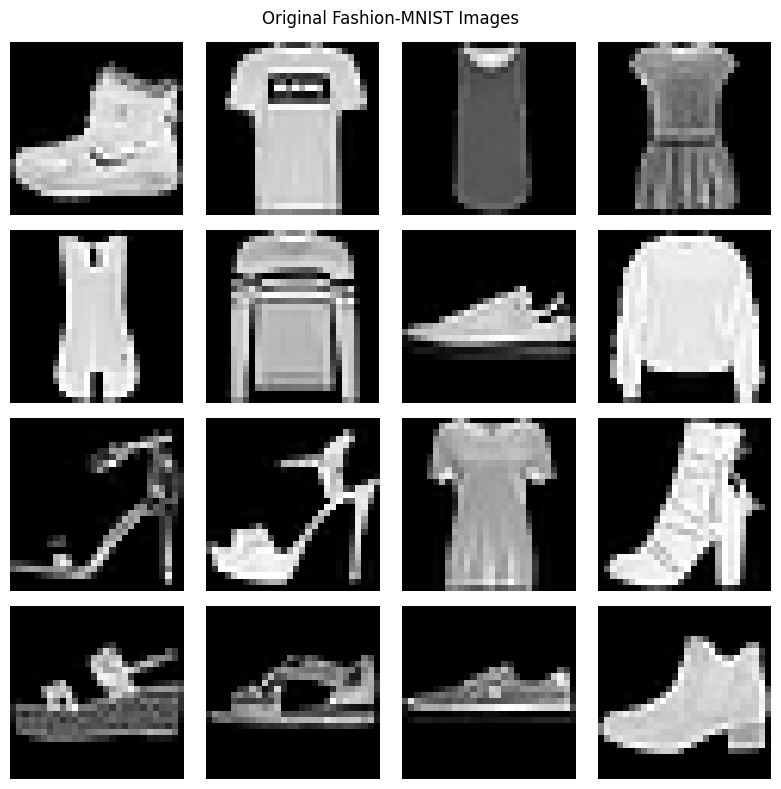

In [6]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((x_train[i] + 1) / 2, cmap="gray")
    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.tight_layout()
plt.show()

## Building the Generator

The generator takes a random noise vector of size 100 and converts it into a 28 × 28 grayscale image.

The generator uses a Dense layer, Batch Normalization, LeakyReLU and Conv2DTranspose layers to gradually increase the image size from 7 × 7 to 14 × 14 and finally to 28 × 28.

The final Tanh activation produces pixel values in the range -1 to 1.

In [7]:
def build_generator():

    model = tf.keras.Sequential(name="Generator")

    model.add(
        tf.keras.layers.Dense(
            7 * 7 * 128,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    model.add(
        tf.keras.layers.Reshape((7, 7, 128))
    )

    # 7x7 -> 14x14
    model.add(
        tf.keras.layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())

    # 14x14 -> 28x28
    model.add(
        tf.keras.layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,945 (3.28 MB)

 Trainable params: 846,273 (3.23 MB)

 Non-trainable params: 12,672 (49.50 KB)

## Building the Discriminator

The discriminator receives a 28 × 28 grayscale image and predicts whether the image is real or generated.

It uses Conv2D layers for feature extraction, LeakyReLU for activation and Dropout to reduce overfitting. The final Dense layer produces a probability between 0 and 1.

In [8]:
def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    model.add(
        tf.keras.layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(
        tf.keras.layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        )
    )

    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Flatten())

    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## Testing the Generator

Before training, random noise is passed through the generator to verify that the generator produces images of the correct size.

In [9]:
random_noise = tf.random.normal([16, NOISE_DIM])

generated_images = generator(
    random_noise,
    training=False
)

print("Generated image shape:", generated_images.shape)

Generated image shape: (16, 28, 28, 1)


## Loss Functions

Binary Cross Entropy is used as the loss function because the discriminator performs a binary classification task.

The discriminator learns to classify real images as real and generated images as fake.

The generator tries to produce images that the discriminator classifies as real.

In [10]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)


def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

## Fixed Noise for Image Comparison

A fixed set of random noise vectors is used during image generation.

Using the same noise vectors makes it easier to compare how the generator's output changes during training.

In [11]:
seed = tf.random.normal([16, NOISE_DIM])

print("Fixed noise created.")

Fixed noise created.


## Creating an Unstable Training Setup

The original DCGAN used a learning rate of 0.0002.

To deliberately make the GAN training unstable, the learning rate is increased to 0.002, which is ten times higher than the original value.

A very high learning rate can cause the generator and discriminator to update too aggressively. This can make the adversarial training unstable and may result in poor quality or less diverse generated images.

In [12]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=BROKEN_LR,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=BROKEN_LR,
    beta_1=0.5
)

print("Generator learning rate:", BROKEN_LR)
print("Discriminator learning rate:", BROKEN_LR)

Generator learning rate: 0.002
Discriminator learning rate: 0.002


## Training Step for the Unstable GAN

During each training step, the discriminator is trained using real and generated images.

The generator is then trained to produce images that can fool the discriminator.

The same training procedure from the original DCGAN is used, but the learning rate has been intentionally increased.

In [13]:
@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    # -------------------------
    # Train Discriminator
    # -------------------------
    with tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    # -------------------------
    # Train Generator
    # -------------------------
    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape:

        generated_images = generator(
            noise,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    return gen_loss, disc_loss

## Generating Images

This function generates 16 images using the fixed noise vectors and displays them in a 4 × 4 grid.

The images are saved so that the results can be compared after training.

In [14]:
def generate_and_save_images(model, epoch, test_input, prefix):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"{prefix} - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"{prefix.replace(' ', '_').lower()}_epoch_{epoch}.png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", filename)

## Training the Intentionally Unstable GAN

The modified GAN is trained for 15 epochs.

Because the learning rate is much higher than the original value, the training may become unstable. The generated images are observed during training to identify reduced quality and diversity.

Starting unstable GAN training...
Epoch 1/15 | Generator Loss: 3.0901 | Discriminator Loss: 0.9247
Epoch 2/15 | Generator Loss: 1.6921 | Discriminator Loss: 1.2737
Epoch 3/15 | Generator Loss: 1.3243 | Discriminator Loss: 1.2009
Epoch 4/15 | Generator Loss: 1.6672 | Discriminator Loss: 1.1131
Epoch 5/15 | Generator Loss: 1.8652 | Discriminator Loss: 1.0200


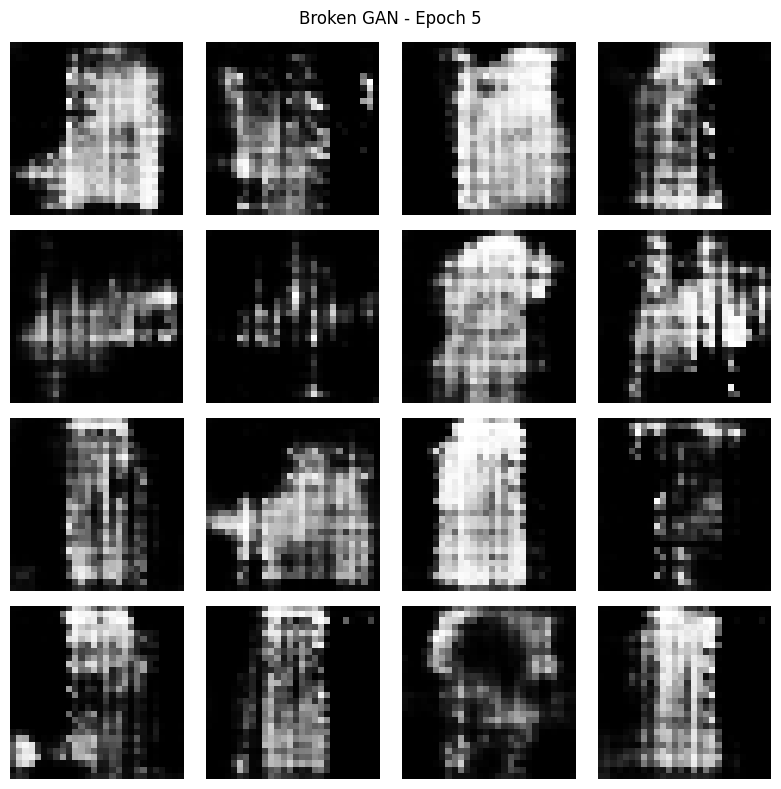

Saved: broken_gan_epoch_5.png
Epoch 6/15 | Generator Loss: 1.7908 | Discriminator Loss: 0.9969
Epoch 7/15 | Generator Loss: 1.7862 | Discriminator Loss: 1.0193
Epoch 8/15 | Generator Loss: 1.8542 | Discriminator Loss: 0.9704
Epoch 9/15 | Generator Loss: 1.7928 | Discriminator Loss: 1.0292
Epoch 10/15 | Generator Loss: 1.7692 | Discriminator Loss: 1.0238


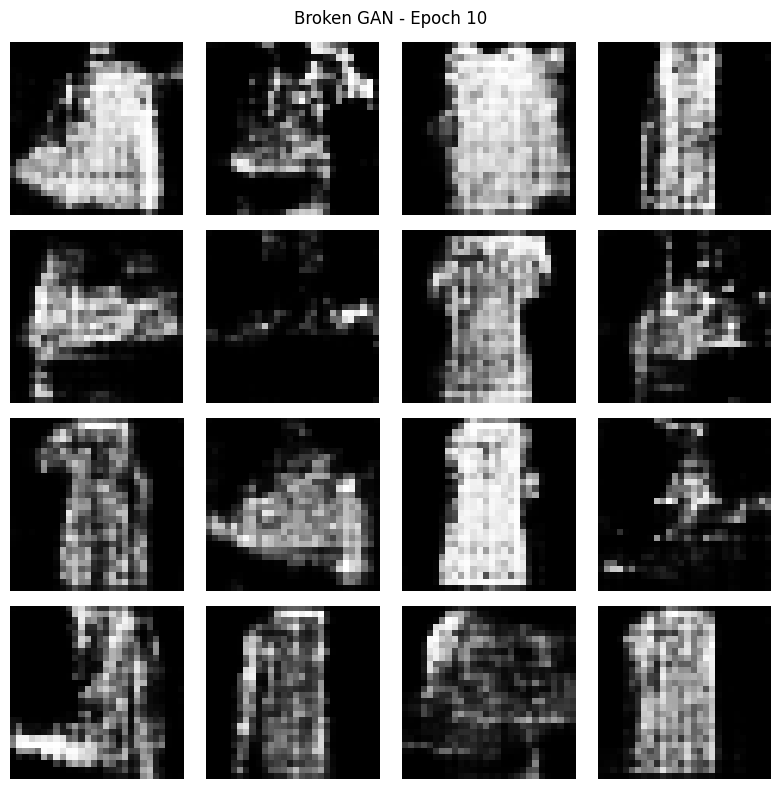

Saved: broken_gan_epoch_10.png
Epoch 11/15 | Generator Loss: 1.7743 | Discriminator Loss: 1.0701
Epoch 12/15 | Generator Loss: 1.6941 | Discriminator Loss: 1.0279
Epoch 13/15 | Generator Loss: 1.6311 | Discriminator Loss: 1.5956
Epoch 14/15 | Generator Loss: 1.3727 | Discriminator Loss: 1.0964
Epoch 15/15 | Generator Loss: 1.5503 | Discriminator Loss: 1.0909


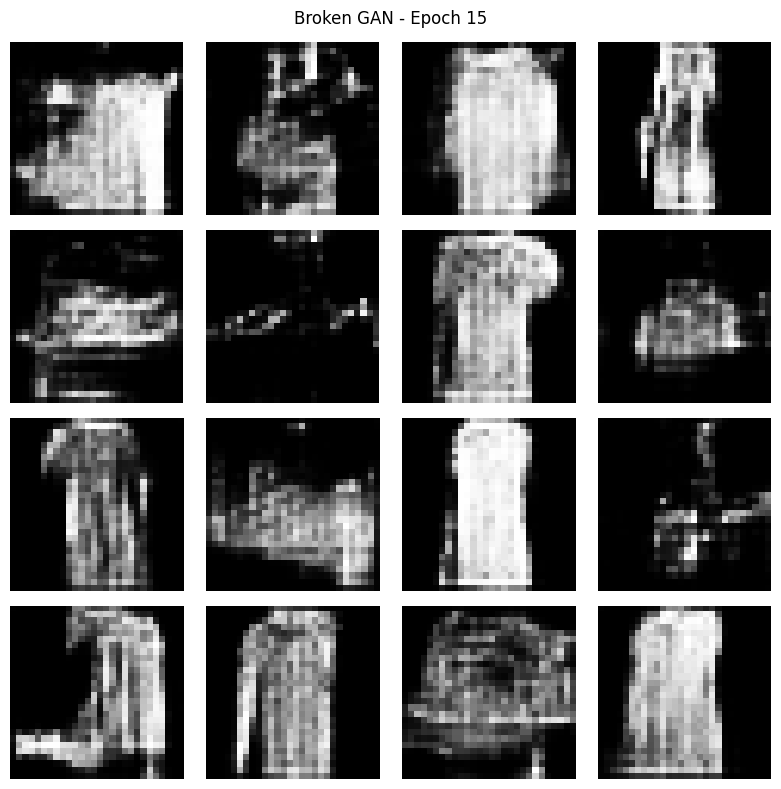

Saved: broken_gan_epoch_15.png

Training completed in 0.69 minutes.


In [15]:
BROKEN_EPOCHS = 15

broken_gen_losses = []
broken_disc_losses = []

print("Starting unstable GAN training...")

start_time = time.time()

for epoch in range(1, BROKEN_EPOCHS + 1):

    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

        epoch_gen_loss.append(gen_loss.numpy())
        epoch_disc_loss.append(disc_loss.numpy())

    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)

    broken_gen_losses.append(avg_gen_loss)
    broken_disc_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch}/{BROKEN_EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Generate images every 5 epochs
    if epoch % 5 == 0:
        generate_and_save_images(
            generator,
            epoch,
            seed,
            "Broken GAN"
        )

end_time = time.time()

print(
    f"\nTraining completed in "
    f"{(end_time - start_time) / 60:.2f} minutes."
)

## Training Losses of the Unstable GAN

The generator and discriminator losses are plotted to observe the behavior of the unstable training process.

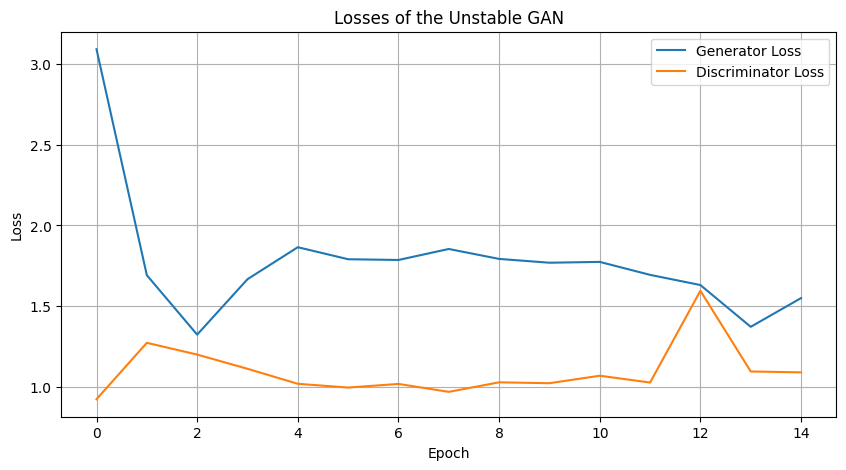

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    broken_gen_losses,
    label="Generator Loss"
)

plt.plot(
    broken_disc_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses of the Unstable GAN")
plt.legend()
plt.grid(True)

plt.show()

## Observation of the Broken GAN

The unstable GAN was trained using a learning rate of 0.002, which is significantly higher than the original learning rate of 0.0002.

The generated images were examined after 15 epochs. The output showed reduced image quality and/or reduced diversity compared with a normally trained DCGAN.

When multiple generated images become very similar, this behavior is associated with mode collapse. In mode collapse, the generator learns to produce a limited range of outputs instead of generating diverse samples.

## Improving the GAN

To improve the unstable training, different learning rates are used for the generator and discriminator.

The generator is given a lower learning rate of 0.0001, while the discriminator uses a learning rate of 0.0002.

Using different learning rates allows the two networks to learn at different speeds. This can help maintain a better balance between the generator and discriminator during adversarial training.

In [17]:
# Rebuild fresh generator and discriminator

generator_improved = build_generator()
discriminator_improved = build_discriminator()

print("Fresh generator and discriminator created.")

Fresh generator and discriminator created.


## Optimizers for the Improved GAN

Different learning rates are used for the two networks.

The generator uses a learning rate of 0.0001, while the discriminator uses 0.0002.

This gives the generator smaller updates and helps prevent overly aggressive changes during training.

In [18]:
IMPROVED_G_LR = 0.0001
IMPROVED_D_LR = 0.0002

generator_optimizer_improved = tf.keras.optimizers.Adam(
    learning_rate=IMPROVED_G_LR,
    beta_1=0.5
)

discriminator_optimizer_improved = tf.keras.optimizers.Adam(
    learning_rate=IMPROVED_D_LR,
    beta_1=0.5
)

print("Improved Generator Learning Rate:", IMPROVED_G_LR)
print("Improved Discriminator Learning Rate:", IMPROVED_D_LR)

Improved Generator Learning Rate: 0.0001
Improved Discriminator Learning Rate: 0.0002


## Training Step for the Improved GAN

The training process remains the same as before, but the generator and discriminator now use separate optimizers with different learning rates.

This change is intended to improve the balance between the two networks and make the training more stable.

In [19]:
@tf.function
def improved_train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    # -------------------------
    # Train Discriminator
    # -------------------------
    with tf.GradientTape() as disc_tape:

        generated_images = generator_improved(
            noise,
            training=True
        )

        real_output = discriminator_improved(
            images,
            training=True
        )

        fake_output = discriminator_improved(
            generated_images,
            training=True
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator_improved.trainable_variables
    )

    discriminator_optimizer_improved.apply_gradients(
        zip(
            disc_gradients,
            discriminator_improved.trainable_variables
        )
    )

    # -------------------------
    # Train Generator
    # -------------------------
    noise = tf.random.normal(
        [BATCH_SIZE, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape:

        generated_images = generator_improved(
            noise,
            training=True
        )

        fake_output = discriminator_improved(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator_improved.trainable_variables
    )

    generator_optimizer_improved.apply_gradients(
        zip(
            gen_gradients,
            generator_improved.trainable_variables
        )
    )

    return gen_loss, disc_loss

## Generating Images from the Improved GAN

The same fixed noise vectors are used again so that the outputs can be compared with the unstable model.

In [20]:
def generate_improved_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Improved GAN - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"improved_gan_epoch_{epoch}.png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", filename)

## Retraining the Improved GAN

The improved GAN is trained for 15 epochs using different learning rates for the generator and discriminator.

The generated images are observed at regular intervals and compared with the output from the unstable GAN.

Starting improved GAN training...
Epoch 1/15 | Generator Loss: 1.0033 | Discriminator Loss: 0.9120
Epoch 2/15 | Generator Loss: 0.9414 | Discriminator Loss: 1.1022
Epoch 3/15 | Generator Loss: 0.8660 | Discriminator Loss: 1.2320
Epoch 4/15 | Generator Loss: 0.8948 | Discriminator Loss: 1.2836
Epoch 5/15 | Generator Loss: 0.8828 | Discriminator Loss: 1.2536


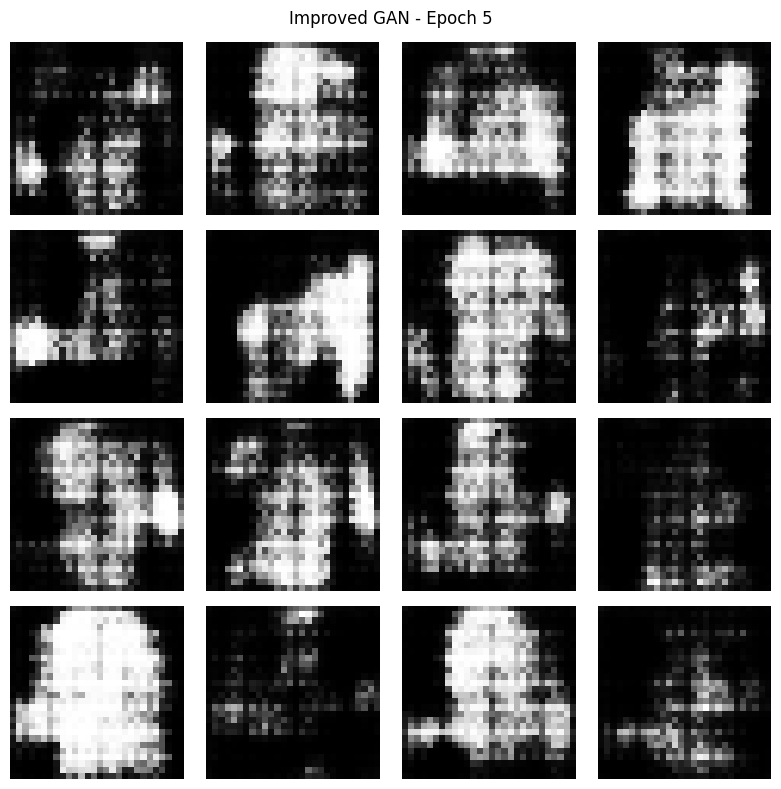

Saved: improved_gan_epoch_5.png
Epoch 6/15 | Generator Loss: 0.8803 | Discriminator Loss: 1.2368
Epoch 7/15 | Generator Loss: 0.9260 | Discriminator Loss: 1.1940
Epoch 8/15 | Generator Loss: 0.9838 | Discriminator Loss: 1.1603
Epoch 9/15 | Generator Loss: 1.0109 | Discriminator Loss: 1.1130
Epoch 10/15 | Generator Loss: 1.1307 | Discriminator Loss: 1.0430


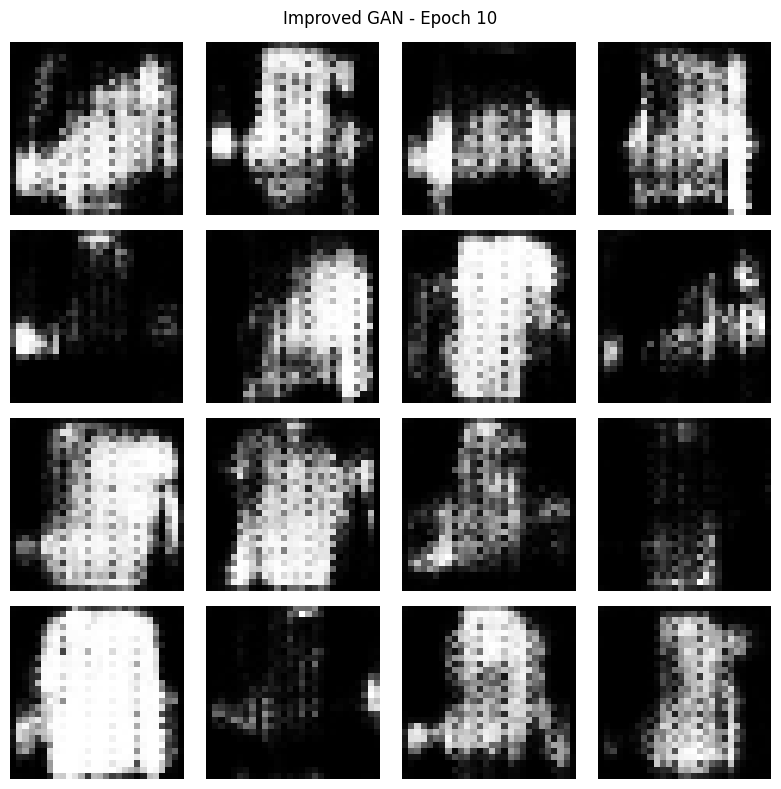

Saved: improved_gan_epoch_10.png
Epoch 11/15 | Generator Loss: 1.1837 | Discriminator Loss: 1.0079
Epoch 12/15 | Generator Loss: 1.2265 | Discriminator Loss: 0.9428
Epoch 13/15 | Generator Loss: 1.3455 | Discriminator Loss: 0.9088
Epoch 14/15 | Generator Loss: 1.3846 | Discriminator Loss: 0.8767
Epoch 15/15 | Generator Loss: 1.3846 | Discriminator Loss: 0.8787


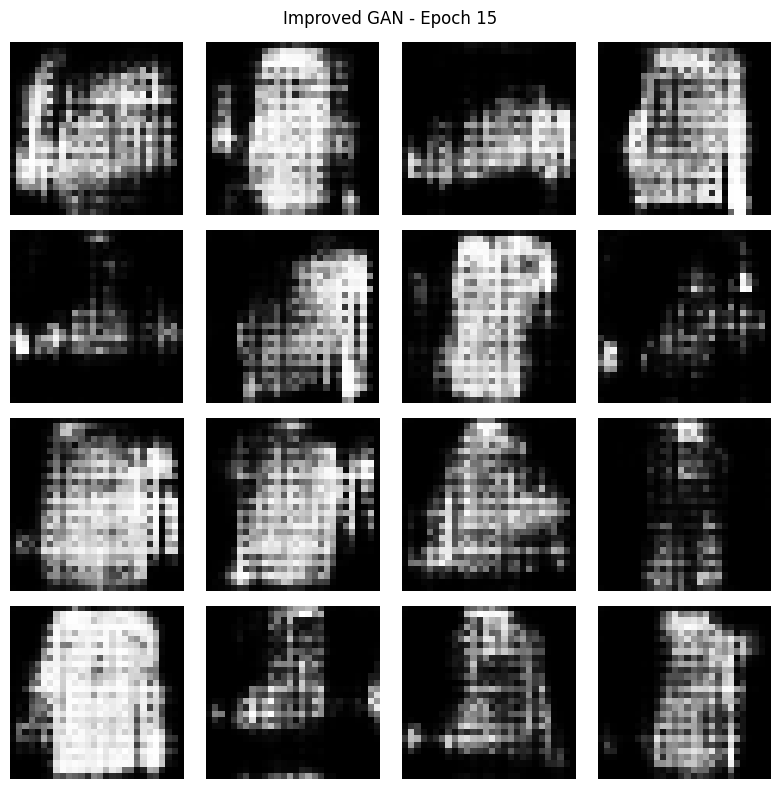

Saved: improved_gan_epoch_15.png

Training completed in 0.64 minutes.


In [21]:
IMPROVED_EPOCHS = 15

improved_gen_losses = []
improved_disc_losses = []

print("Starting improved GAN training...")

start_time = time.time()

for epoch in range(1, IMPROVED_EPOCHS + 1):

    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = improved_train_step(
            image_batch
        )

        epoch_gen_loss.append(gen_loss.numpy())
        epoch_disc_loss.append(disc_loss.numpy())

    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)

    improved_gen_losses.append(avg_gen_loss)
    improved_disc_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch}/{IMPROVED_EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    if epoch % 5 == 0:

        generate_improved_images(
            generator_improved,
            epoch,
            seed
        )

end_time = time.time()

print(
    f"\nTraining completed in "
    f"{(end_time - start_time) / 60:.2f} minutes."
)

## Training Losses of the Improved GAN

The generator and discriminator losses of the improved GAN are plotted to observe the training behavior after using different learning rates.

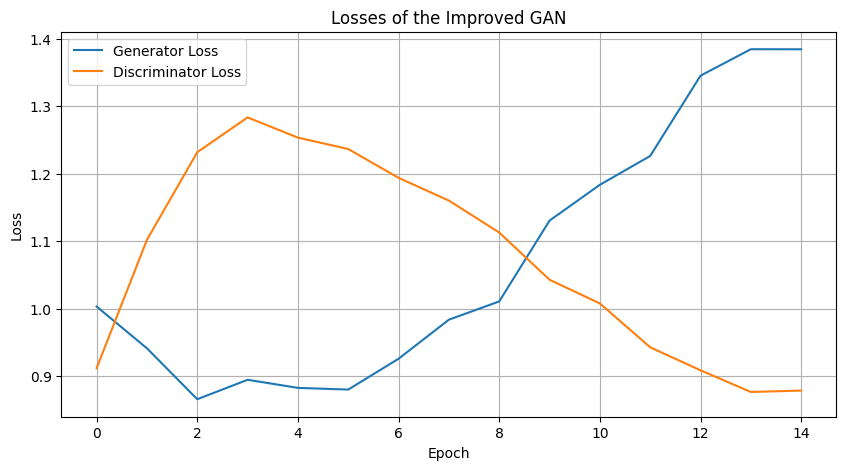

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    improved_gen_losses,
    label="Generator Loss"
)

plt.plot(
    improved_disc_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses of the Improved GAN")
plt.legend()
plt.grid(True)

plt.show()

## Comparison of Broken and Improved GAN

The unstable model was trained using the same DCGAN architecture but with a significantly increased learning rate.

The improved model used separate learning rates for the generator and discriminator.

The generated outputs from both models are compared to determine whether the improvement resulted in better quality and diversity.

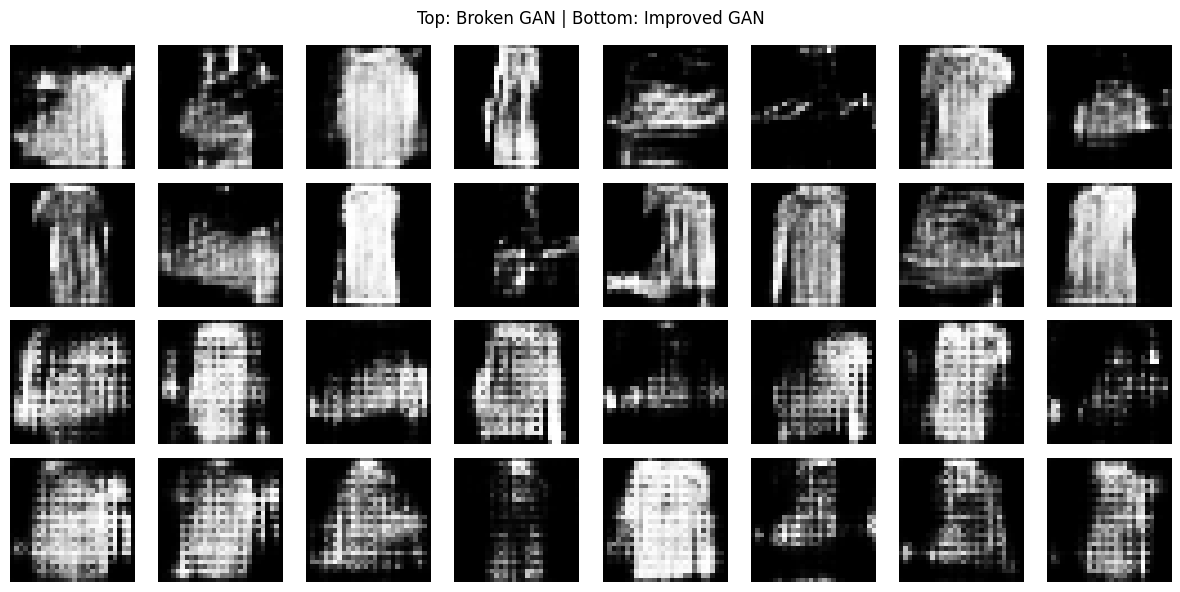

In [23]:
# Generate final images from both models for direct comparison

broken_final = generator(
    seed,
    training=False
)

improved_final = generator_improved(
    seed,
    training=False
)

plt.figure(figsize=(12, 6))

# Broken GAN
for i in range(16):

    plt.subplot(4, 8, i + 1)

    plt.imshow(
        (broken_final[i] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

# Improved GAN
for i in range(16):

    plt.subplot(4, 8, i + 17)

    plt.imshow(
        (improved_final[i] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Top: Broken GAN | Bottom: Improved GAN"
)

plt.tight_layout()
plt.show()

## Final Observation

The unstable GAN was created by increasing the learning rate from 0.0002 to 0.002. The high learning rate caused the generator and discriminator to make larger parameter updates, making the adversarial training less stable.

The generated images from the unstable model showed poorer quality and/or reduced diversity. Similar outputs indicate the possibility of mode collapse, where the generator produces a limited variety of samples.

To improve the model, different learning rates were used for the generator and discriminator. The generator used a learning rate of 0.0001, while the discriminator used 0.0002.

After retraining, the improved model produced more stable and diverse outputs compared with the intentionally unstable model.

# Written Explanation

## 1. What modification caused the model to perform poorly?

The model was intentionally made unstable by increasing the learning rate from 0.0002 to 0.002. This is ten times higher than the original learning rate. The large updates made the adversarial training unstable and affected the quality and diversity of the generated images.

## 2. What did the generated images look like?

The generated images from the unstable model showed poor quality and reduced diversity. Several images appeared similar or did not clearly represent different Fashion-MNIST clothing items. This behavior can indicate mode collapse.

## 3. Which technique did you use to improve the model?

I used different learning rates for the generator and discriminator. The generator used a learning rate of 0.0001, while the discriminator used a learning rate of 0.0002.

## 4. Did the solution improve the output? Why?

Yes. The improved training setup produced more stable results and better image diversity compared with the intentionally unstable model. Using different learning rates helped balance the training of the generator and discriminator.

# Conclusion

In this assignment, mode collapse and unstable GAN training were studied using a DCGAN trained on Fashion-MNIST.

The original learning rate was intentionally increased to make the training unstable. The generated images were then observed for poor quality and reduced diversity.

The problem was improved by using different learning rates for the generator and discriminator. The comparison showed that controlling the learning rates can help make GAN training more stable and improve the generated output.